Importing all the required libraries for pre-processing and model training

In [262]:
# ====================================
# STEP 1: Import Libraries
# ====================================
!pip install catboost xgboost lightgbm -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
!pip install missingno
import missingno as msno


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\saikr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\saikr\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [263]:
# Target variable balance
print("=== Target: h1n1_vaccine ===")
print(train['h1n1_vaccine'].value_counts())
print()
print(train['h1n1_vaccine'].value_counts(normalize=True).round(3))
print()

=== Target: h1n1_vaccine ===
h1n1_vaccine
0    2882
1    1874
Name: count, dtype: int64

h1n1_vaccine
0    0.606
1    0.394
Name: proportion, dtype: float64



In [264]:
#  Identifying all the Data types present in the dataset
print("=== Column data types ===")
print(train.dtypes)
print()


=== Column data types ===
respondent_id                    int64
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
age_group                       object
education                       object
race                            object
sex                             object
income_poverty                  object
marital_status                  object
rent_or_own                     object

In [265]:
train= pd.read_csv("/content/dataset_B_training.csv") # reading the data from csv file
# Shape of the training dataset
print(train.shape)
train.head()
test = pd.read_csv("/content/dataset_B_testing.csv")# reading the data from test csv file

(4756, 31)


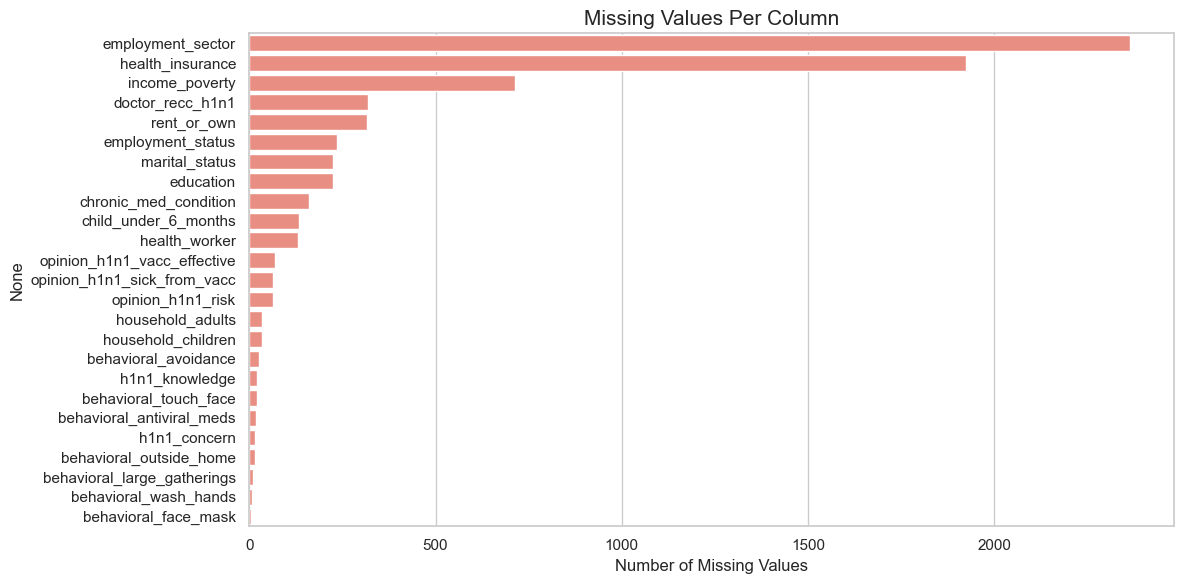


Columns with missing values:
employment_sector              2364
health_insurance               1925
income_poverty                  712
doctor_recc_h1n1                319
rent_or_own                     315
employment_status               235
marital_status                  226
education                       224
chronic_med_condition           161
child_under_6_months            134
health_worker                   131
opinion_h1n1_vacc_effective      69
opinion_h1n1_sick_from_vacc      64
opinion_h1n1_risk                64
household_adults                 34
household_children               34
behavioral_avoidance             27
h1n1_knowledge                   22
behavioral_touch_face            20
behavioral_antiviral_meds        17
h1n1_concern                     15
behavioral_outside_home          15
behavioral_large_gatherings       9
behavioral_wash_hands             8
behavioral_face_mask              4
dtype: int64


In [266]:
missing= train.isnull().sum() # identifying the missing values
missing = missing[missing > 0].sort_values(ascending=False) # sorting the columns based on number of missing values

plt.figure(figsize=(12, 6)) #plotting a  bar plot to show the missing values coloumns and number of missing values
sns.barplot(x=missing.values, y=missing.index, color='salmon')
plt.title('Missing Values Per Column', fontsize=15)
plt.xlabel('Number of Missing Values')
plt.tight_layout()
plt.show()

print(f"\nColumns with missing values:\n{missing}") # prinitng the values

In [267]:
# Look at the unique values in each text/categorical column
cat_cols = train.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    print(f"--- {col}  ({train[col].nunique()} unique values) ---")
    print(train[col].value_counts(dropna=False).to_string())
    print()

--- age_group  (5 unique values) ---
age_group
65+ Years        1225
55 - 64 Years    1065
45 - 54 Years     913
18 - 34 Years     894
35 - 44 Years     659

--- education  (4 unique values) ---
education
College Graduate    1858
Some College        1270
12 Years            1009
< 12 Years           395
NaN                  224

--- race  (4 unique values) ---
race
White                3831
Black                 324
Other or Multiple     305
Hispanic              296

--- sex  (2 unique values) ---
sex
Female    2921
Male      1835

--- income_poverty  (3 unique values) ---
income_poverty
<= $75,000, Above Poverty    2250
> $75,000                    1342
NaN                           712
Below Poverty                 452

--- marital_status  (2 unique values) ---
marital_status
Married        2535
Not Married    1995
NaN             226

--- rent_or_own  (2 unique values) ---
rent_or_own
Own     3466
Rent     975
NaN      315

--- employment_status  (3 unique values) ---
employment_st

<Axes: >

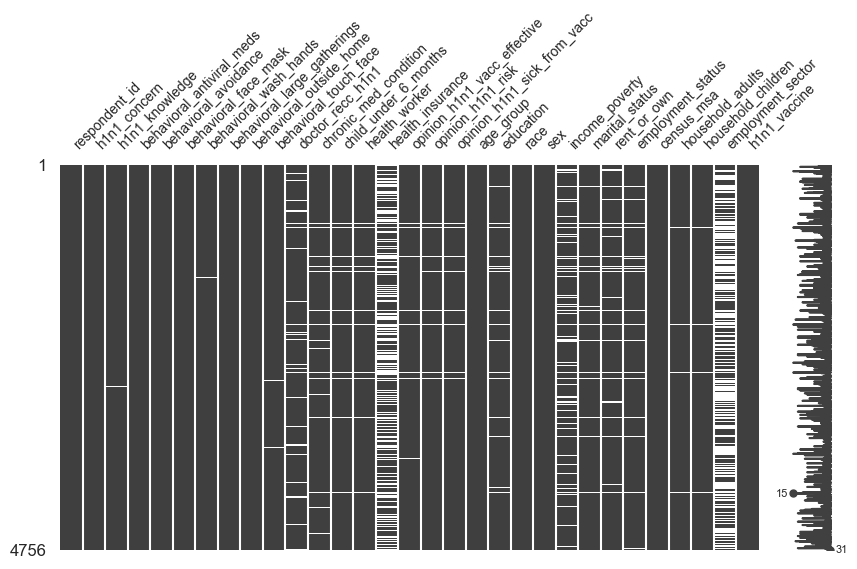

In [269]:
# Make a heat map of all the missing values using the missingno package
# (see https://github.com/ResidentMario/missingno for more information)
# Show missing values:
msno.matrix(train,figsize=(10,5),fontsize=10)

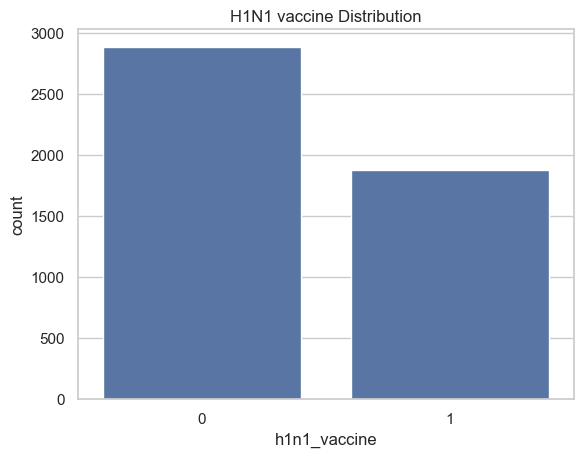

In [270]:
sns.countplot(x="h1n1_vaccine",data= train)
plt.title("H1N1 vaccine Distribution")
plt.show()

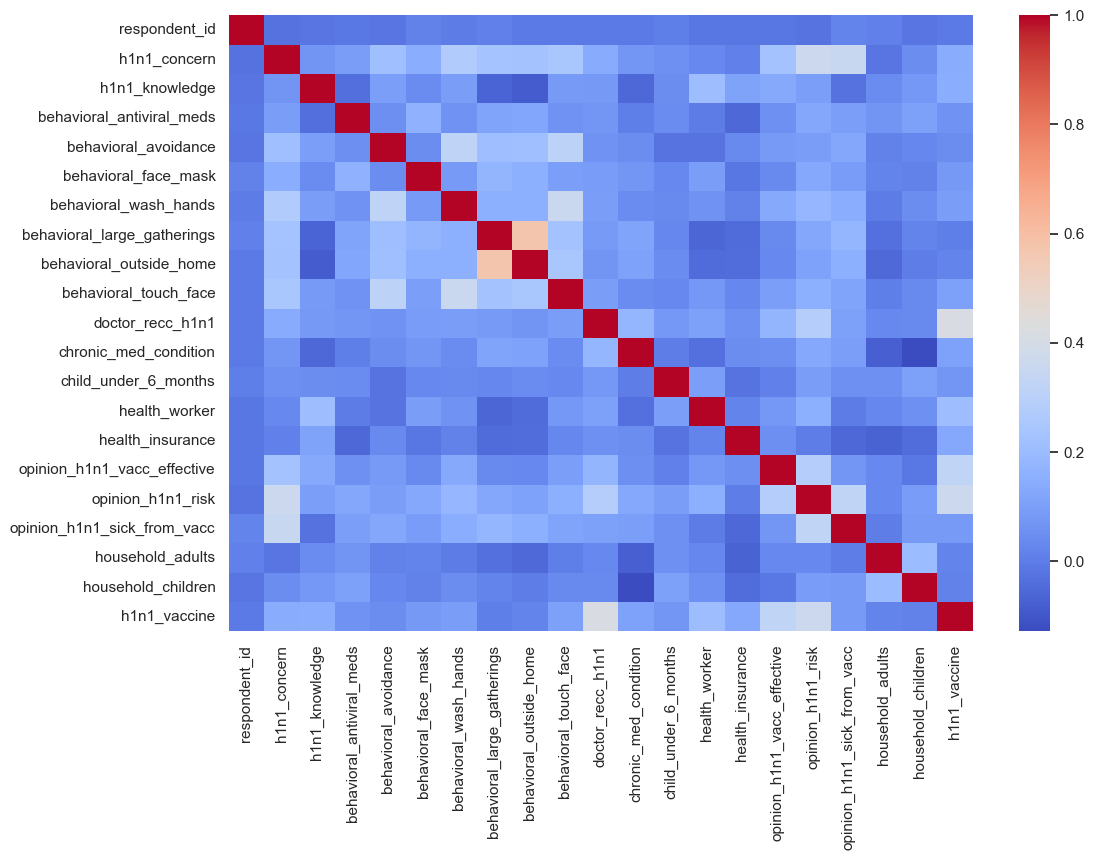

In [271]:
plt.figure(figsize=(12,8))

sns.heatmap(
    train.select_dtypes(include=np.number).corr(),
    cmap='coolwarm'
)

plt.show()

In [272]:
train["h1n1_vaccine"].value_counts()

h1n1_vaccine
0    2882
1    1874
Name: count, dtype: int64

# **Feature Engineering**

In [273]:
train["prevention_score"] = (
    train["behavioral_face_mask"] +
    train["behavioral_wash_hands"] +
    train["behavioral_avoidance"]
)

test["prevention_score"] = (
    test["behavioral_face_mask"] +
    test["behavioral_wash_hands"] +
    test["behavioral_avoidance"]
)

# **Preparing the data**

In [274]:
#Removing respondent_id because it is only an identifier
X = train.drop(
    ["respondent_id", "h1n1_vaccine"],
    axis=1
)
#target variable to be predicted
y = train["h1n1_vaccine"]
#Test data to be used for final prediction
X_test = test.drop(
    ["respondent_id"],
    axis=1
)

# **Train Validation Split**


In [275]:
X_train, X_valid, y_train, y_valid = train_test_split(  # splitting the dataset into train and validation sets
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y# stratify ensures the same class distribution is applied
)

# **Preprocessing**

In [276]:

num_cols = X.select_dtypes(
    include=["int64","float64"]
).columns

cat_cols = X.select_dtypes(
    include=["object"]
).columns
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        num_cols
    ),
    (
        "cat",
        categorical_transformer,
        cat_cols
    )
])

# **Logistic Regression**

In [277]:
#Logistic Regression used as a baseline model and provides a simple linear classification benchmark
log_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_valid)
log_probs = log_model.predict_proba(X_valid)[:,1]

log_acc = accuracy_score(y_valid, log_preds)
log_f1 = f1_score(y_valid, log_preds)
log_auc = roc_auc_score(y_valid, log_probs)

print("Logistic")
print("Accuracy:", log_acc)
print("F1:", log_f1)
print("ROC AUC:", log_auc)

Logistic
Accuracy: 0.7573529411764706
F1: 0.6685796269727403
ROC AUC: 0.816152512998267


# **Random** **Forest**

In [278]:
#Random forest used to capture the non-linear relations and interactions between features
rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_valid)
rf_probs = rf_model.predict_proba(X_valid)[:,1]

rf_acc = accuracy_score(y_valid, rf_preds)
rf_f1 = f1_score(y_valid, rf_preds)
rf_auc = roc_auc_score(y_valid, rf_probs)

print("Random Forest")
print("Accuracy:", rf_acc)
print("F1:", rf_f1)
print("ROC AUC:", rf_auc)

Random Forest
Accuracy: 0.7489495798319328
F1: 0.6571018651362984
ROC AUC: 0.7994061236279607


# **XGBoost Model**

In [289]:
# this is an gradient boosting algorithm
#This usually performs better on strongly tabulated data
xgb_model = Pipeline([
    ("prep", preprocessor),
    ("model", XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_valid)
xgb_probs = xgb_model.predict_proba(X_valid)[:,1]

xgb_acc = accuracy_score(y_valid, xgb_preds)
xgb_f1 = f1_score(y_valid, xgb_preds)
xgb_auc = roc_auc_score(y_valid, xgb_probs)

print("XGBoost")
print("Accuracy:", xgb_acc)
print("F1:", xgb_f1)
print("ROC AUC:", xgb_auc)

XGBoost
Accuracy: 0.7510504201680672
F1: 0.6685314685314685
ROC AUC: 0.8032998266897747


# **CatBoost Models**

In [279]:
#this model handles categorical variables very efficiently
#and also robust to missing values
cat_X = X.copy()
cat_X_test = X_test.copy()

cat_features = cat_X.select_dtypes(
    include=["object"]
).columns.tolist()

for col in cat_features:
    cat_X[col] = cat_X[col].fillna("Missing")
    cat_X_test[col] = cat_X_test[col].fillna("Missing")

X_train_cb, X_valid_cb, y_train_cb, y_valid_cb = train_test_split(
    cat_X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# **CatBoost Depth=6**

In [280]:
from catboost import CatBoostClassifier

cat6_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    eval_metric="AUC",
    verbose=0
)

cat6_model.fit(
    X_train_cb,
    y_train_cb,
    cat_features=cat_features
)

cat6_preds = cat6_model.predict(X_valid_cb)
cat6_probs = cat6_model.predict_proba(X_valid_cb)[:,1]

cat6_acc = accuracy_score(y_valid_cb, cat6_preds)
cat6_f1 = f1_score(y_valid_cb, cat6_preds)
cat6_auc = roc_auc_score(y_valid_cb, cat6_probs)

# **CatBoost Depth = 8**

In [281]:
cat8_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=8,
    eval_metric="AUC",
    verbose=0
)

cat8_model.fit(
    X_train_cb,
    y_train_cb,
    cat_features=cat_features
)

cat8_preds = cat8_model.predict(X_valid_cb)
cat8_probs = cat8_model.predict_proba(X_valid_cb)[:,1]

cat8_acc = accuracy_score(y_valid_cb, cat8_preds)
cat8_f1 = f1_score(y_valid_cb, cat8_preds)
cat8_auc = roc_auc_score(y_valid_cb, cat8_probs)

# **Comparing All the Models Results**

In [287]:
#Evaluating model performance using accuracy,f1score, Roc-auc

results = pd.DataFrame({
    "Model":[
        "Logistic",
        "Random Forest",
        "XGBoost",
        "CatBoost D6",
        "CatBoost D8"
    ],
    "Accuracy":[
        log_acc,
        rf_acc,
        xgb_acc,
        cat6_acc,
        cat8_acc
    ],
    "F1":[
        log_f1,
        rf_f1,
        xgb_f1,
        cat6_f1,
        cat8_f1
    ],
    "ROC_AUC":[
        log_auc,
        rf_auc,
        xgb_auc,
        cat6_auc,
        cat8_auc
    ]
})

results.sort_values(
    "ROC_AUC",
    ascending=True
)

,Model,Accuracy,F1,ROC_AUC
1,Random Forest,0.748950,0.657102,0.799406
2,XGBoost,0.751050,0.668531,0.803300
0,Logistic,0.757353,0.668580,0.816153
4,CatBoost D8,0.785714,0.713483,0.841100
3,CatBoost D6,0.778361,0.702398,0.844354


# **Identifying all the important features in dataset for model training and accuracy**

In [283]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat6_model.get_feature_importance()
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(15))

                        Feature  Importance
9              doctor_recc_h1n1    9.658493
13             health_insurance    9.240116
15            opinion_h1n1_risk    9.144150
14  opinion_h1n1_vacc_effective    8.220380
17                    age_group    6.226775
28            employment_sector    5.443050
16  opinion_h1n1_sick_from_vacc    5.089237
18                    education    4.750293
19                         race    4.074440
21               income_poverty    4.040432
25                   census_msa    3.932671
24            employment_status    3.484167
0                  h1n1_concern    3.183350
22               marital_status    2.950390
12                health_worker    2.495826


# **Predicting the results on train dataset and generating all the files required for submission**

In [288]:
log_model.fit(X, y)# retraining models using the full training dataset before generating predictions for the hidden values
rf_model.fit(X, y)
xgb_model.fit(X, y)

cat6_model.fit(
    cat_X,
    y,
    cat_features=cat_features,
    verbose=0
)

cat8_model.fit(
    cat_X,
    y,
    cat_features=cat_features,
    verbose=0
)

pred_log = log_model.predict(X_test)
pred_rf = rf_model.predict(X_test)
pred_xgb = xgb_model.predict(X_test)

pred_cat6 = cat6_model.predict(cat_X_test)
pred_cat8 = cat8_model.predict(cat_X_test)

files = {
    "challenge_submission_group_J_order_3.csv": pred_log,
    "challenge_submission_group_J_order_5.csv": pred_rf,
    "challenge_submission_group_J_order_4.csv": pred_xgb,
    "challenge_submission_group_J_order_2.csv": pred_cat6,
    "challenge_submission_group_J_order_1.csv": pred_cat8
}

for file, preds in files.items():
    pd.DataFrame({
        "respondent_id": test["respondent_id"],
        "h1n1_vaccine": preds.astype(int)
    }).to_csv(file, index=False)

print("All 5 submission files created.")

All 5 submission files created.
